In [2]:
import numpy as np
import pandas as pd

from nilearn import datasets
from nilearn.maskers import NiftiMasker
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from nilearn.image import index_img
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, f1_score
from nilearn import plotting


haxby = datasets.fetch_haxby(subjects=[1, 2, 3, 4, 5, 6])



[fetch_haxby] Dataset found in /Users/prashantkondayapalepu/nilearn_data/haxby2001


In [3]:
func_files = haxby.func
labels_files = haxby.session_target

print("Subjects:", len(func_files))

from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn.maskers import NiftiLabelsMasker



Subjects: 6


In [4]:
atlas = fetch_atlas_schaefer_2018(n_rois=400)
masker = NiftiLabelsMasker(labels_img=atlas.maps, standardize=True)

all_X = []
all_y = []

for func_file, labels_file in zip(func_files, labels_files):
    time_series = masker.fit_transform(func_file)

    labels = pd.read_csv(labels_file, sep=" ")
    y = (labels["labels"] != "rest").astype(int).values

    min_len = min(len(y), len(time_series))
    all_X.append(time_series[:min_len])
    all_y.append(y[:min_len])

X = np.concatenate(all_X, axis=0)
y = np.concatenate(all_y, axis=0)

print("Final shape:", X.shape, y.shape)

[fetch_atlas_schaefer_2018] Dataset found in /Users/prashantkondayapalepu/nilearn_data/schaefer_2018


/var/folders/jh/d3xlhzqd5cb_vrt1mb900fxc0000gn/T/ipykernel_29654/3565474862.py:8: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(func_file)
/var/folders/jh/d3xlhzqd5cb_vrt1mb900fxc0000gn/T/ipykernel_29654/3565474862.py:8: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(func_file)
/var/folders/jh/d3xlhzqd5cb_vrt1

Final shape: (8712, 400) (8712,)



Showing brain slice...


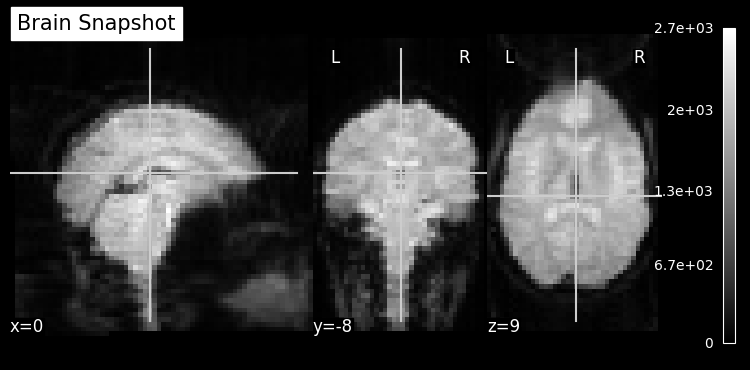

In [5]:
print("\nShowing brain slice...")
img_3d = index_img(func_files[0], 0)
plotting.plot_epi(img_3d, title="Brain Snapshot")
plotting.show()


[fetch_atlas_schaefer_2018] Dataset found in /Users/prashantkondayapalepu/nilearn_data/schaefer_2018


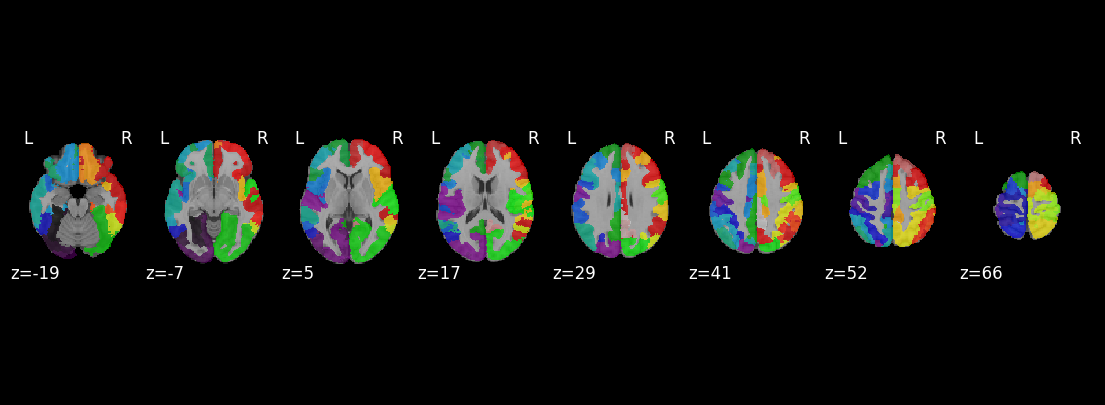

In [ ]:
from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn import plotting
import matplotlib.pyplot as plt

atlas = fetch_atlas_schaefer_2018(n_rois=400)

fig, ax = plt.subplots(figsize=(14, 5), facecolor='black')
display = plotting.plot_roi(
    atlas.maps,
    axes=ax,
    cmap='nipy_spectral',  
    colorbar=False,       
    black_bg=True,         
    display_mode='z',     
    cut_coords=8           
)
plt.savefig('atlas_400.png', bbox_inches='tight', facecolor='black', dpi=150)

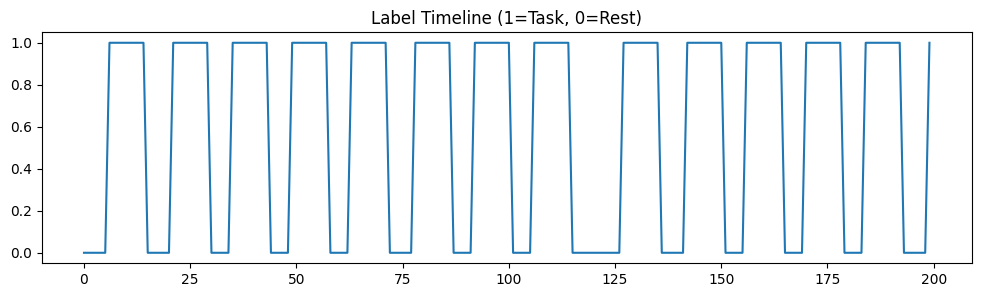

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))
plt.plot(y[:200])
plt.title("Label Timeline (1=Task, 0=Rest)") 
plt.show()

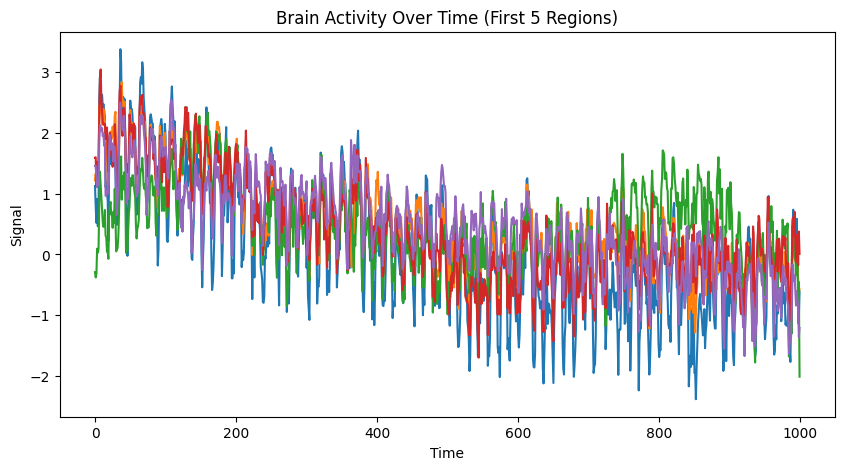

In [8]:
plt.figure(figsize=(10,5))
plt.plot(X[:1000, :5])
plt.title("Brain Activity Over Time (First 5 Regions)")
plt.xlabel("Time")
plt.ylabel("Signal")
plt.show()

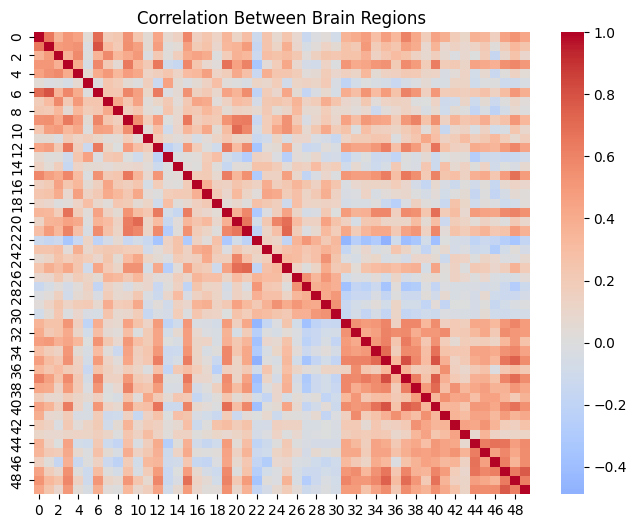

In [9]:
corr = np.corrcoef(X[:, :50].T)

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Between Brain Regions")
plt.show()

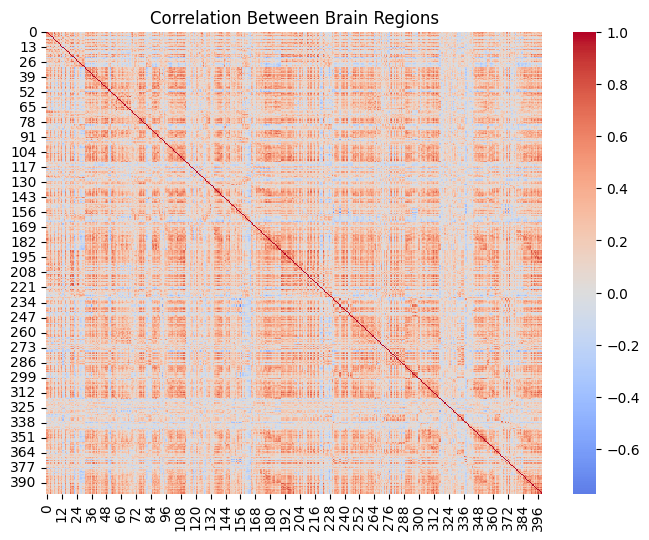

In [10]:
corr = np.corrcoef(X.T)

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Between Brain Regions")
plt.show()

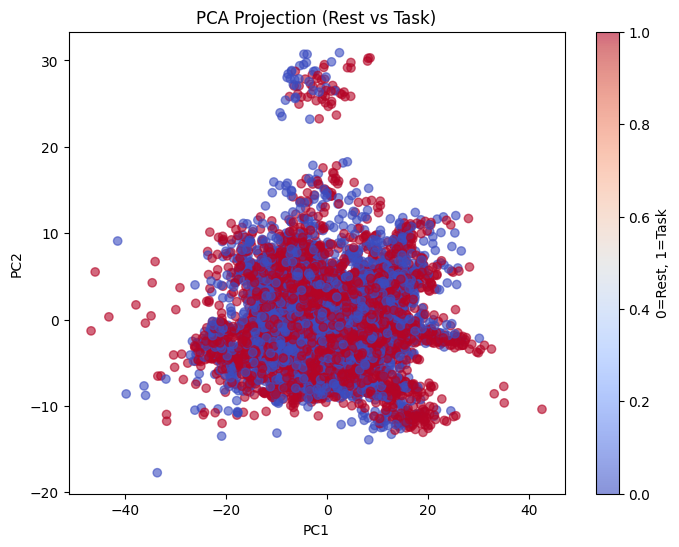

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="coolwarm", alpha=0.6)
plt.title("PCA Projection (Rest vs Task)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="0=Rest, 1=Task")
plt.show()


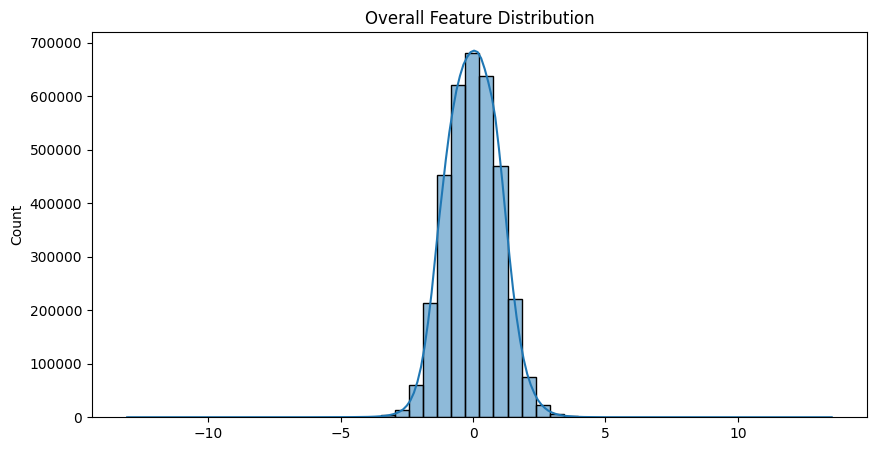

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(X.flatten(), bins=50, kde=True)
plt.title("Overall Feature Distribution")
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    random_state=42 
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nClassification Results:\n")
print(classification_report(y_test, y_pred))


Classification Results:

              precision    recall  f1-score   support

           0       0.90      0.76      0.82       764
           1       0.83      0.94      0.88       979

    accuracy                           0.86      1743
   macro avg       0.87      0.85      0.85      1743
weighted avg       0.86      0.86      0.86      1743



In [14]:
importances = model.feature_importances_

all_idx = np.argsort(importances)[::-1]  

top_idx = [i for i in all_idx if atlas.labels[i] != 'Background'][:10]

# 4. Print
print("Top important brain regions:")
for i in top_idx:
    print(i, atlas.labels[i])


Top important brain regions:
255 7Networks_RH_SomMot_25
1 7Networks_LH_Vis_1
3 7Networks_LH_Vis_3
394 7Networks_RH_Default_pCunPCC_3
204 7Networks_RH_Vis_4
194 7Networks_LH_Default_pCunPCC_5
205 7Networks_RH_Vis_5
201 7Networks_RH_Vis_1
396 7Networks_RH_Default_pCunPCC_5
192 7Networks_LH_Default_pCunPCC_3


In [15]:
print("Top Predictive Brain Regions:\n")
for i in top_idx:
    label = atlas.labels[i]
    
    if 'Default' in label and 'pCunPCC' in label:
        area = "Precuneus / Posterior Cingulate (Default Mode Network)"
    elif 'Vis' in label:
        area = "Visual Cortex"
    elif 'SomMot' in label:
        area = "Somatomotor Cortex"
    elif 'DorsAttn' in label:
        area = "Dorsal Attention Network"
    elif 'SalVentAttn' in label:
        area = "Salience / Ventral Attention Network"
    elif 'Limbic' in label:
        area = "Limbic System"
    elif 'Cont' in label:
        area = "Frontoparietal Control Network"
    elif 'TempPar' in label:
        area = "Temporal Parietal Junction"
    else:
        area = "Other Cortical Region"
    
    hemi = "Right Hemisphere" if 'RH' in label else "Left Hemisphere"
    print(f"{label}")
    print(f"  → {area} | {hemi}\n")

Top Predictive Brain Regions:

7Networks_RH_SomMot_25
  → Somatomotor Cortex | Right Hemisphere

7Networks_LH_Vis_1
  → Visual Cortex | Left Hemisphere

7Networks_LH_Vis_3
  → Visual Cortex | Left Hemisphere

7Networks_RH_Default_pCunPCC_3
  → Precuneus / Posterior Cingulate (Default Mode Network) | Right Hemisphere

7Networks_RH_Vis_4
  → Visual Cortex | Right Hemisphere

7Networks_LH_Default_pCunPCC_5
  → Precuneus / Posterior Cingulate (Default Mode Network) | Left Hemisphere

7Networks_RH_Vis_5
  → Visual Cortex | Right Hemisphere

7Networks_RH_Vis_1
  → Visual Cortex | Right Hemisphere

7Networks_RH_Default_pCunPCC_5
  → Precuneus / Posterior Cingulate (Default Mode Network) | Right Hemisphere

7Networks_LH_Default_pCunPCC_3
  → Precuneus / Posterior Cingulate (Default Mode Network) | Left Hemisphere



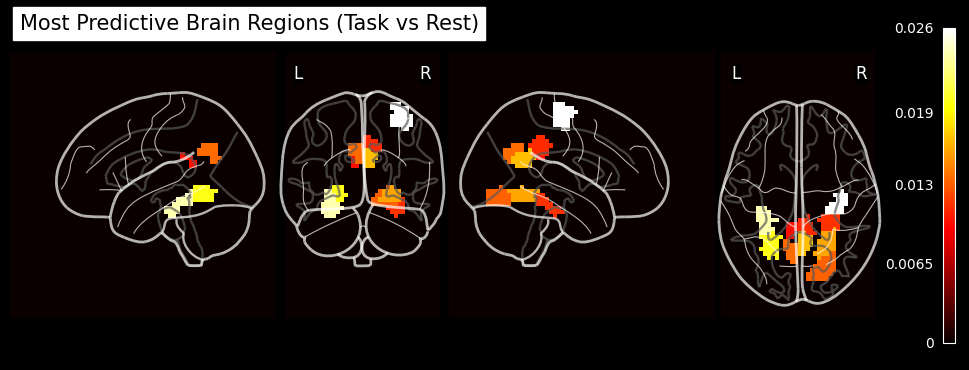

In [ ]:
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np

# Use importance values
region_values = np.zeros(400)
for i in top_idx:
    region_values[i] = importances[i]

brain_img = masker.inverse_transform(region_values)

display = plotting.plot_glass_brain(
    brain_img,
    display_mode='lyrz',
    black_bg=True,
    colorbar=True,
    cmap='hot',
    vmax=importances[top_idx[0]],
    plot_abs=True,         
    title="Most Predictive Brain Regions (Task vs Rest)",
)

plt.savefig('brain_regions.png', facecolor='black', 
            bbox_inches='tight', dpi=200)
plotting.show()

In [ ]:
print("Label positions for PowerPoint:")
importances = model.feature_importances_
all_idx = np.argsort(importances)[::-1]
top_idx = [i for i in all_idx if atlas.labels[i] != 'Background'][:10]

for i in top_idx:
    label = atlas.labels[i]
    if 'Default' in label:   area = 'Default Mode Network'
    elif 'Vis' in label:     area = 'Visual Cortex'
    elif 'SomMot' in label:  area = 'Somatomotor'
    else:                    area = label.split('_')[-1]
    hemi = 'RH' if 'RH' in label else 'LH'
    print(f"→ {area} ({hemi})")


Label positions for PowerPoint:
→ Somatomotor (RH)
→ Visual Cortex (LH)
→ Visual Cortex (LH)
→ Default Mode Network (RH)
→ Visual Cortex (RH)
→ Default Mode Network (LH)
→ Visual Cortex (RH)
→ Visual Cortex (RH)
→ Default Mode Network (RH)
→ Default Mode Network (LH)


Region Legend:
1. [YELLOW] SomMot 25 — Somatomotor
2. [CYAN] Vis 1 — Visual Cortex
3. [CYAN] Vis 3 — Visual Cortex
4. [RED] pCunPCC 3 — Default Mode
5. [CYAN] Vis 4 — Visual Cortex
6. [RED] pCunPCC 5 — Default Mode
7. [CYAN] Vis 5 — Visual Cortex
8. [CYAN] Vis 1 — Visual Cortex
9. [RED] pCunPCC 5 — Default Mode
10. [RED] pCunPCC 3 — Default Mode

Color Key:
        yellow → Somatomotor
          cyan → Visual Cortex
           red → Default Mode


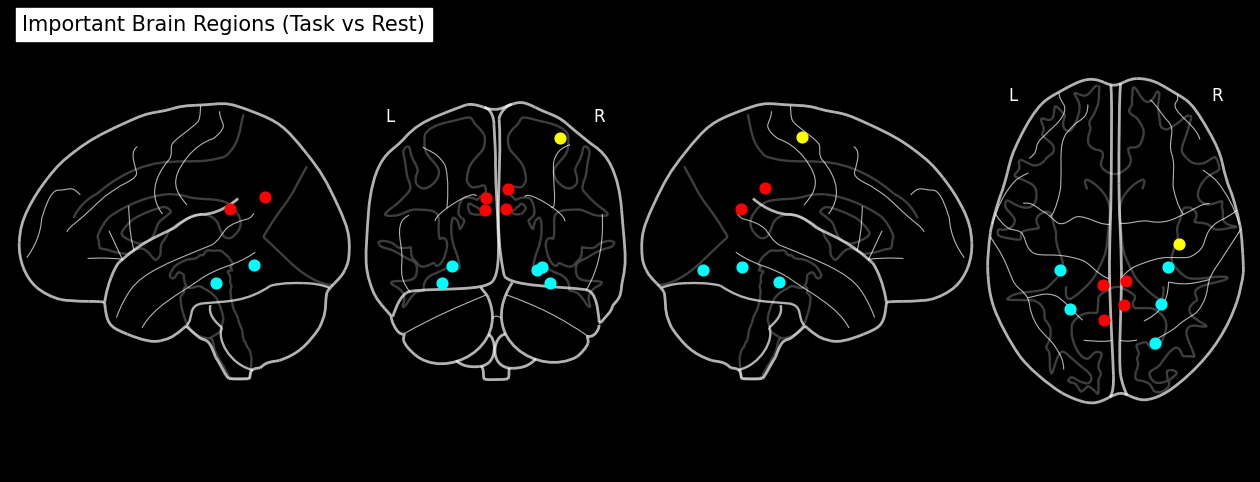

In [ ]:
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np

coords = []
names = []
importance_vals = []
network_labels = []

importances = model.feature_importances_
all_idx = np.argsort(importances)[::-1]
top_idx = [i for i in all_idx if atlas.labels[i] != 'Background'][:10]

def get_network(label):
    if 'Default' in label:
        return 'Default Mode'
    elif 'Vis' in label:
        return 'Visual Cortex'
    elif 'SomMot' in label:
        return 'Somatomotor'
    elif 'DorsAttn' in label:
        return 'Dorsal Attention'
    elif 'SalVentAttn' in label:
        return 'Salience/Ventral Attention'
    elif 'Limbic' in label:
        return 'Limbic'
    elif 'Cont' in label:
        return 'Frontoparietal'
    else:
        return 'Other'

NETWORK_COLORS = {
    'Default Mode':              'red',
    'Visual Cortex':             'cyan',
    'Somatomotor':               'yellow',
    'Dorsal Attention':          'lime',
    'Salience/Ventral Attention':'orange',
    'Limbic':                    'magenta',
    'Frontoparietal':            'deepskyblue',
    'Other':                     'white',
}

for i in top_idx:
    region_img = image.math_img(f"img == {i+1}", img=atlas.maps)
    coord = plotting.find_xyz_cut_coords(region_img)
    coords.append(coord)
    importance_vals.append(importances[i])

    label = atlas.labels[i]
    parts = label.split('_')
    short = parts[-2] + ' ' + parts[-1] if len(parts) >= 2 else label
    names.append(short)
    network_labels.append(get_network(label))

fig, ax = plt.subplots(figsize=(16, 6), facecolor='black')

display = plotting.plot_glass_brain(
    None,
    display_mode='lyrz',
    black_bg=True,
    title="Important Brain Regions (Task vs Rest)",
    figure=fig,
    axes=ax
)

for coord, val, name, network in zip(coords, importance_vals, names, network_labels):
    color = NETWORK_COLORS[network]
    display.add_markers([coord], marker_color=color, marker_size=60)


print("Region Legend:")
for idx, (i, name, network) in enumerate(zip(top_idx, names, network_labels)):
    color = NETWORK_COLORS[network]
    print(f"{idx+1}. [{color.upper()}] {name} — {network}")


print("\nColor Key:")
seen = set()
for network in network_labels:
    if network not in seen:
        print(f"  {NETWORK_COLORS[network]:>12} → {network}")
        seen.add(network)

plotting.show()

In [51]:
for idx, i in enumerate(top_idx):
    region_img = image.math_img(f"img == {i+1}", img=atlas.maps)
    coord = plotting.find_xyz_cut_coords(region_img)
    label = atlas.labels[i]
    if 'Default' in label:   area = 'Default Mode Network'
    elif 'Vis' in label:     area = 'Visual Cortex'
    elif 'SomMot' in label:  area = 'Somatomotor'
    else:                    area = label.split('_')[-1]
    hemi = 'RH' if 'RH' in label else 'LH'
    print(f"Dot {idx+1}: coord={np.round(coord).astype(int)} → {area} ({hemi})")

Dot 1: coord=[ 36 -18  63] → Somatomotor (RH)
Dot 2: coord=[-30 -33 -18] → Visual Cortex (LH)
Dot 3: coord=[-24 -55  -8] → Visual Cortex (LH)
Dot 4: coord=[  6 -52  23] → Default Mode Network (RH)
Dot 5: coord=[ 26 -52  -9] → Visual Cortex (RH)
Dot 6: coord=[ -5 -60  30] → Default Mode Network (LH)
Dot 7: coord=[ 23 -74 -11] → Visual Cortex (RH)
Dot 8: coord=[ 31 -31 -18] → Visual Cortex (RH)
Dot 9: coord=[  7 -38  35] → Default Mode Network (RH)
Dot 10: coord=[ -6 -41  23] → Default Mode Network (LH)


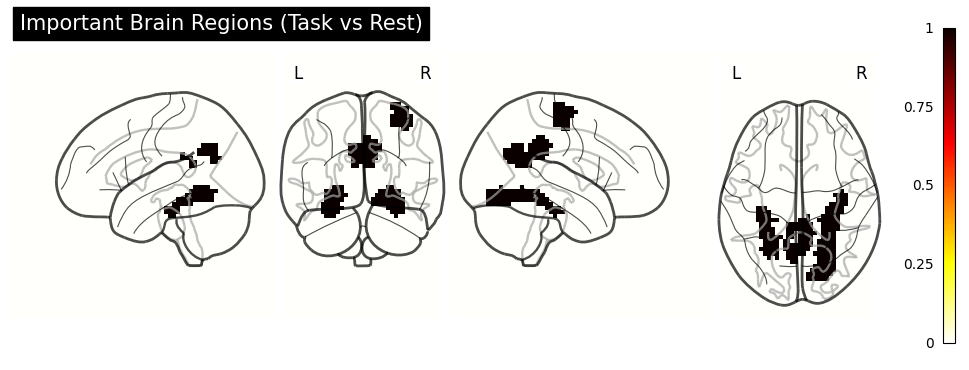

In [ ]:



region_values = np.zeros(400)  


for i in top_idx:
    region_values[i] = 1


brain_img = masker.inverse_transform(region_values)


plotting.plot_glass_brain(
    brain_img,
    display_mode='lyrz',
    colorbar=True,
    title="Important Brain Regions (Task vs Rest)"
)

plotting.show()

In [15]:
df = pd.DataFrame(X)

print("\nFeature stats:")
print(df.describe().T[['mean','std']].head())


Feature stats:
           mean       std
0  1.401511e-14  1.000057
1 -8.613618e-14  1.000057
2 -3.801958e-14  1.000057
3 -4.142875e-14  1.000057
4 -2.093132e-14  1.000057


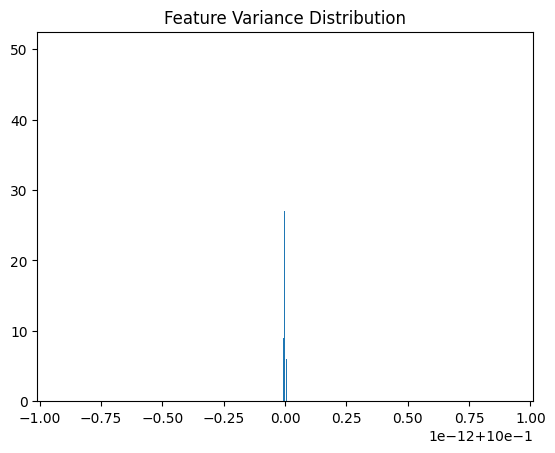

In [16]:
variance = np.var(X, axis=0)

plt.hist(variance, bins=30)
plt.title("Feature Variance Distribution")
plt.show()

In [17]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report


better_model = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=400)),
    ('svm', SVC(kernel='rbf', C=50, gamma='scale', probability = True, random_state=42))
])

better_model.fit(X_train, y_train)
y_pred_better = better_model.predict(X_test)

print("Better Model Results:\n")
print(classification_report(y_test, y_pred_better))

Better Model Results:

              precision    recall  f1-score   support

           0       0.92      0.85      0.88       764
           1       0.89      0.94      0.91       979

    accuracy                           0.90      1743
   macro avg       0.90      0.90      0.90      1743
weighted avg       0.90      0.90      0.90      1743



Working on individual model now

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
import numpy as np


In [41]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_lagged = np.hstack([X_scaled[1:], X_scaled[:-1]])
y_lagged = y[1:]

pca = PCA(n_components= 0.99)
X_pca = pca.fit_transform(X_lagged)

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_pca, y_lagged, test_size=0.2, random_state=123
)

X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_train_np, y_train_np, test_size=0.2, random_state=123
)

X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_np,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_np,  dtype=torch.float32) 
y_train_t = torch.tensor(y_train_np, dtype=torch.float32)
y_val_t   = torch.tensor(y_val_np,   dtype=torch.float32)
y_test_t  = torch.tensor(y_test_np,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=32)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=32)

In [40]:
class BrainNet(nn.Module):
    def __init__(self, input_dim):
        super(BrainNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.35),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, 1),
        )
    

    def forward(self, x):
        return self.network(x).squeeze()

model_nn = BrainNet(input_dim=X_train_np.shape[1])

In [44]:
import copy

neg = (y == 0).sum()
pos = (y == 1).sum()
pos_weight = torch.tensor([neg / pos * 0.40]) 

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight,
    reduction='mean'
)
#optimizer = optim.Adam(model_nn.parameters(), lr=0.001, weight_decay= 0)
optimizer = optim.Adam(model_nn.parameters(), lr=0.0001, weight_decay= 1e-2)
#scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200, eta_min = 1e-6)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=15)

best_val_loss = float('inf')
best_model_state = None
patience = 100
patience_counter = 0

epochs = 400
for epoch in range(epochs):
    model_nn.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model_nn(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()



    model_nn.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            preds = model_nn(X_batch)
            val_loss += criterion(preds, y_batch).item()

    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model_nn.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Train Loss: {total_loss/len(train_loader):.4f} | Val Loss: {avg_val_loss:.4f}")

model_nn.load_state_dict(best_model_state)
print(f"\nLoaded best model with val loss: {best_val_loss:.4f}")

Epoch 10/400 — Train Loss: 0.0575 | Val Loss: 0.1589
Epoch 20/400 — Train Loss: 0.0407 | Val Loss: 0.1585
Epoch 30/400 — Train Loss: 0.0362 | Val Loss: 0.1722
Epoch 40/400 — Train Loss: 0.0327 | Val Loss: 0.1685
Epoch 50/400 — Train Loss: 0.0290 | Val Loss: 0.1698
Epoch 60/400 — Train Loss: 0.0288 | Val Loss: 0.1716
Epoch 70/400 — Train Loss: 0.0318 | Val Loss: 0.1778
Epoch 80/400 — Train Loss: 0.0305 | Val Loss: 0.1809
Epoch 90/400 — Train Loss: 0.0330 | Val Loss: 0.1721
Epoch 100/400 — Train Loss: 0.0282 | Val Loss: 0.1688
Early stopping at epoch 101

Loaded best model with val loss: 0.1378


In [43]:
model_nn.eval()
with torch.no_grad():
    logits = model_nn(X_test_t)
    y_pred_prob = torch.sigmoid(logits).numpy()

with torch.no_grad():
    val_logits = model_nn(X_val_t)
    y_val_prob = torch.sigmoid(val_logits).numpy()

thresholds = np.linspace(0.2, 0.8, 61)
f1s = [f1_score(y_val_np, (y_val_prob >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1s)]
print(f"Best threshold: {best_thresh:.2f}")

y_pred_nn = (y_pred_prob >= best_thresh).astype(int)
print("\nNeural Network Results:\n")
print(classification_report(y_test_np, y_pred_nn))



Best threshold: 0.26

Neural Network Results:

              precision    recall  f1-score   support

           0       0.88      0.89      0.89       742
           1       0.92      0.91      0.92      1001

    accuracy                           0.90      1743
   macro avg       0.90      0.90      0.90      1743
weighted avg       0.90      0.90      0.90      1743



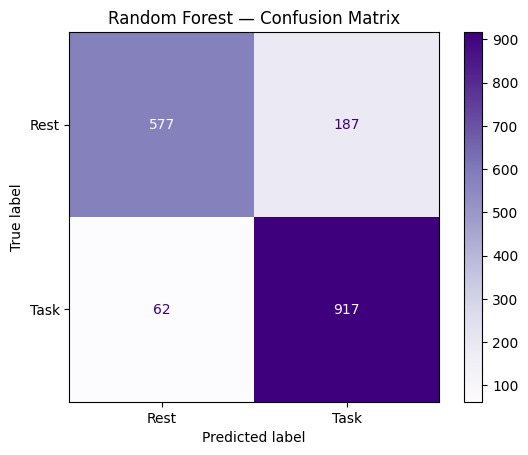

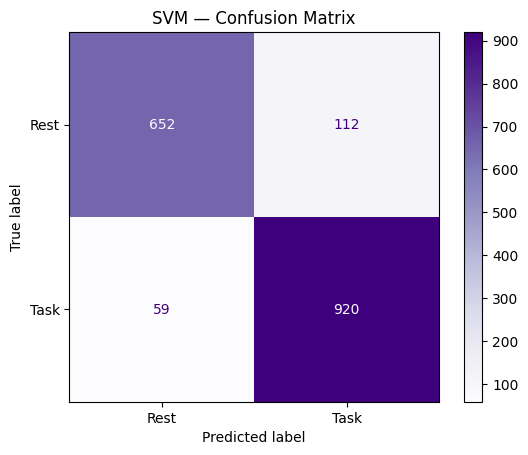

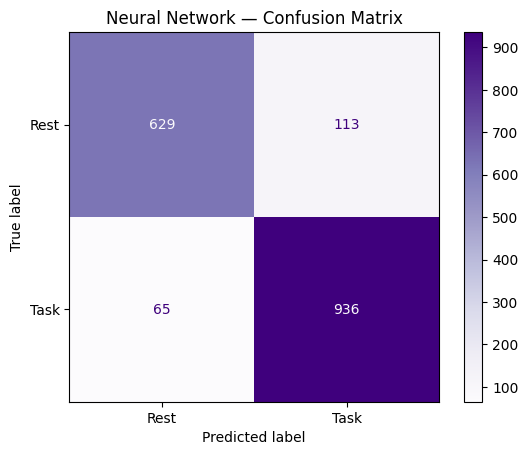

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt


cm_rf = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Rest", "Task"])
disp.plot(cmap="Purples")
plt.title("Random Forest — Confusion Matrix")
plt.show()

cm_svm = confusion_matrix(y_test, y_pred_better)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Rest", "Task"])
disp.plot(cmap="Purples")
plt.title("SVM — Confusion Matrix")
plt.show()

cm_nn = confusion_matrix(y_test_np, y_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=["Rest", "Task"])
disp.plot(cmap="Purples")
plt.title("Neural Network — Confusion Matrix")
plt.show()

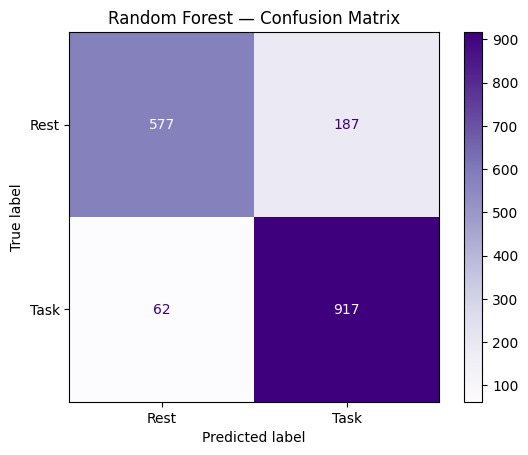

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
# Run for each model (replace y_pred with each model's predictions)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rest", "Task"])
disp.plot(cmap="Purples")
plt.title("Random Forest — Confusion Matrix")
plt.show()

[fetch_atlas_schaefer_2018] Dataset found in /Users/prashantkondayapalepu/nilearn_data/schaefer_2018


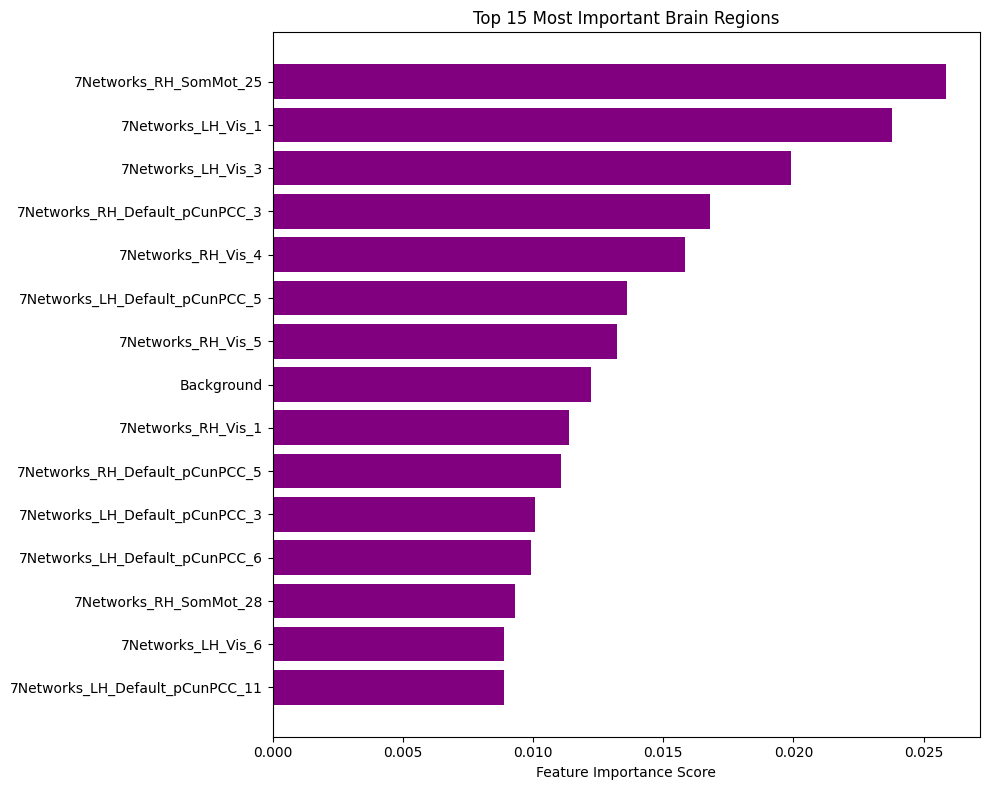

In [25]:
from nilearn.datasets import fetch_atlas_schaefer_2018
import numpy as np
import matplotlib.pyplot as plt

atlas = fetch_atlas_schaefer_2018(n_rois=400)
atlas_labels = [label.decode('utf-8') if isinstance(label, bytes) else label 
                for label in atlas.labels]

importances = model.feature_importances_
top_idx = np.argsort(importances)[-15:]

plt.figure(figsize=(10,8))
plt.barh(range(15), importances[top_idx], color="purple")
plt.yticks(range(15), [atlas_labels[i] for i in top_idx])
plt.title("Top 15 Most Important Brain Regions")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()